# exp-gs-002-07 — 일준님 A_pair only + log1p 적응 실험

현재 best `H-AS + exact 4개 + 혼동쌍 contrast`를 유지하고, 기존 A 전체(ref/alt/pair/position)를 `A_pair 380개 only`로 교체한다. B/V/A_pair count에는 `log1p`를 적용한다. 외부 파일 import 없이 변이 문자열에서 직접 생성한다.

In [1]:
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

def find_eda_dir():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct=path/'common'/'exp-gs-002-memory-safe.py'
        project=path/'experiments'/'gs'/'notebooks'/'eda_pre_002'/'common'/'exp-gs-002-memory-safe.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('프로젝트 루트 또는 eda_pre_002에서 실행하세요.')

EDA_DIR=find_eda_dir(); ROOT=EDA_DIR.parents[3]
RUNNER=EDA_DIR/'common'/'exp-gs-002-memory-safe.py'; RESULT_DIR=EDA_DIR/'result'
RUN_ID='exp-gs-002-07'; MODEL='logistic'; SEEDS=(42,2024,777)
BASELINE='H-AS-LR-exact-confusion-pairs'
CANDIDATE='H-AS-LR-exact-confusion-pairs-Apair-log1p'
assert RUNNER.exists() and RESULT_DIR.exists()
{'baseline':BASELINE,'candidate':CANDIDATE,'seeds':SEEDS,'fixed_model':'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced','feature_rule':'A_pair 380 only; B/V/A_pair log1p; marginals and position excluded'}

/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'baseline': 'H-AS-LR-exact-confusion-pairs',
 'candidate': 'H-AS-LR-exact-confusion-pairs-Apair-log1p',
 'seeds': (42, 2024, 777),
 'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
 'feature_rule': 'A_pair 380 only; B/V/A_pair log1p; marginals and position excluded'}

## 실행
기본값은 `False`다. True로 변경하면 3-seed 실행과 공통 실행기 fold tqdm이 표시된다.

In [2]:
RUN_EXPERIMENT=True
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS,desc=f'{RUN_ID} | 3-seed',unit='seed'):
        command=[sys.executable,str(RUNNER),'--run-id',RUN_ID,'--candidate',CANDIDATE,'--model',MODEL,'--seed',str(seed)]
        done=subprocess.run(command,cwd=ROOT,check=False)
        if done.returncode != 0: raise RuntimeError(f'seed={seed} 실행 실패: {done.returncode}')
else:
    print('미실행 상태입니다. RUN_EXPERIMENT = True로 변경하세요.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 382.45it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 42: 100%|██████████| 5/5 [03:23<00:00, 40.74s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.47814168846488037,
  "oof_accuracy": 0.45879696823093047,
  "fold_macro_f1_mean": 0.47829869725520846,
  "fold_macro_f1_std": 0.008298637176475701,
  "feature_count_mean": 8175.2,
  "runtime_seconds": 203.7985974999974,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 398.47it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 2024: 100%|██████████| 5/5 [03:17<00:00, 39.57s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4762175133106753,
  "oof_accuracy": 0.4594420254797613,
  "fold_macro_f1_mean": 0.47455525475426424,
  "fold_macro_f1_std": 0.016029343519538886,
  "feature_count_mean": 8175.0,
  "runtime_seconds": 197.94426833399484,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 389.41it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 777: 100%|██████████| 5/5 [03:06<00:00, 37.35s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.481145738774279,
  "oof_accuracy": 0.4613771972262538,
  "fold_macro_f1_mean": 0.48023186500651416,
  "fold_macro_f1_std": 0.016618944095251567,
  "feature_count_mean": 8170.4,
  "runtime_seconds": 186.81298162500025,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


exp-gs-002-07 | 3-seed: 100%|██████████| 3/3 [11:06<00:00, 222.05s/seed]


## 3-seed 비교
06 best와 직접 비교한다. validation/test를 피처 선택에 사용하지 않으며 `leakage_check=True`, `nan_as_mutation_count=0`이 모두 필요하다.

,experiment_id,seed_count,macro_f1_mean,macro_f1_std,feature_count_mean,convergence_warning_count,delta_vs_06_best
1,H-AS-LR-exact-confusion-pairs-Apair-log1p,3,0.478502,0.002484,8173.533333,0,0.040006
0,H-AS-LR-exact-confusion-pairs,3,0.438495,0.004021,8219.533333,15,0.000000


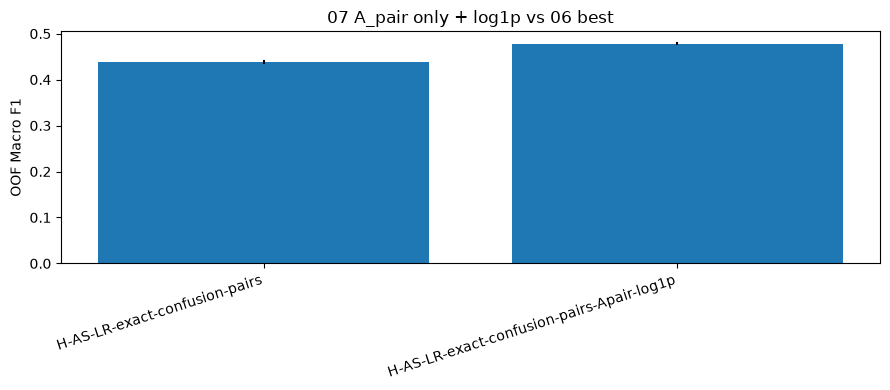

In [3]:
def oof_path(run_id,candidate,seed): return RESULT_DIR/f'{run_id}_{candidate}_{MODEL}_seed{seed}_oof.csv'
candidate_paths=[oof_path(RUN_ID,CANDIDATE,s) for s in SEEDS]
baseline_paths=[oof_path('exp-gs-002-06',BASELINE,s) for s in SEEDS]
missing=[p for p in candidate_paths+baseline_paths if not p.exists()]
if missing:
    print('필요한 결과 파일이 없습니다:'); [print(' -',p.name) for p in missing]
else:
    runs=pd.concat([pd.read_csv(p) for p in candidate_paths+baseline_paths],ignore_index=True)
    assert runs.leakage_check.all() and (runs.nan_as_mutation_count==0).all()
    summary=runs.groupby('experiment_id',as_index=False).agg(seed_count=('seed','nunique'),macro_f1_mean=('oof_macro_f1','mean'),macro_f1_std=('oof_macro_f1','std'),feature_count_mean=('feature_count_mean','mean'),convergence_warning_count=('convergence_warning_count','sum'))
    baseline=summary.loc[summary.experiment_id.eq(BASELINE),'macro_f1_mean'].iloc[0]
    summary['delta_vs_06_best']=summary.macro_f1_mean-baseline
    summary.to_csv(RESULT_DIR/f'{RUN_ID}_3seed_summary.csv',index=False)
    display(summary.sort_values('macro_f1_mean',ascending=False))
    plt.figure(figsize=(9,4)); plt.bar(summary.experiment_id,summary.macro_f1_mean,yerr=summary.macro_f1_std); plt.xticks(rotation=18,ha='right'); plt.ylabel('OOF Macro F1'); plt.title('07 A_pair only + log1p vs 06 best'); plt.tight_layout(); plt.show()